In [2]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy
import seaborn as sb
import src.concept_utils as cu


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl

2025-10-14 14:06:00.759971: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-14 14:06:00.952228: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-10-14 14:06:01.911776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
sys.path.append(os.getcwd())
sys.path

['/home/thomas/.conda/envs/debiafting/lib/python313.zip',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13/lib-dynload',
 '',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages',
 '/tmp/tmpfy1ugkss',
 '/home/thomas/Documents/ENS/IAS/S2/XCL/CVDB']

<Axes: >

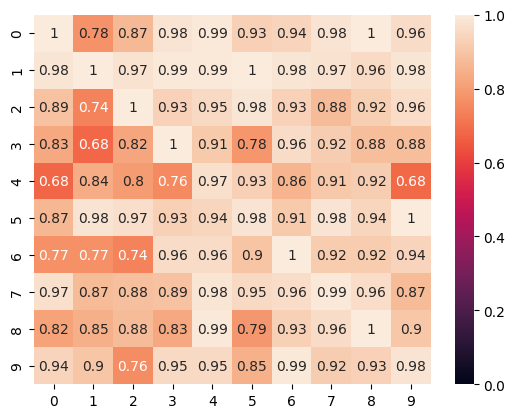

In [9]:
exp_id = 1
exp_name = "MNIST"
with open("models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
    model_res = pkl.load(f)
sb.heatmap(model_res["correctness_matrix"]/model_res["appearance_matrix"], vmin=0, vmax=1, annot=True)


In [5]:
with open(f"models/{exp_name}/concepts_{0}_{1}.pkl", "rb") as f:
    concept_res = pkl.load(f)

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
amount_of_concept = 30
studied_bias = 8
step_amount = 70

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 10 concept, the vector similarity is : [0.         0.00263658 0.00339212 0.02473486 0.0261782  0.11336766
 0.15514128 0.15718385]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 30 concept, the vector similarity is : [0.00033411 0.02851303 0.03760341 0.0735846  0.09306819 0.12050533
 0.12075749 0.11752144]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


...

For 100 concept, the vector similarity is : [0.00161919 0.0213218  0.0661349  0.11569177 0.14679773 0.16270327
 0.18106745 0.1749787 ]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 300 concept, the vector similarity is : [0.00402002 0.04303413 0.09320572 0.12733336 0.15575767 0.17267356
 0.18270627 0.17973914]


/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


For 500 concept, the vector similarity is : [0.0080961  0.04847345 0.10805613 0.15098697 0.15765938 0.17895726
 0.17837728 0.1869421 ]


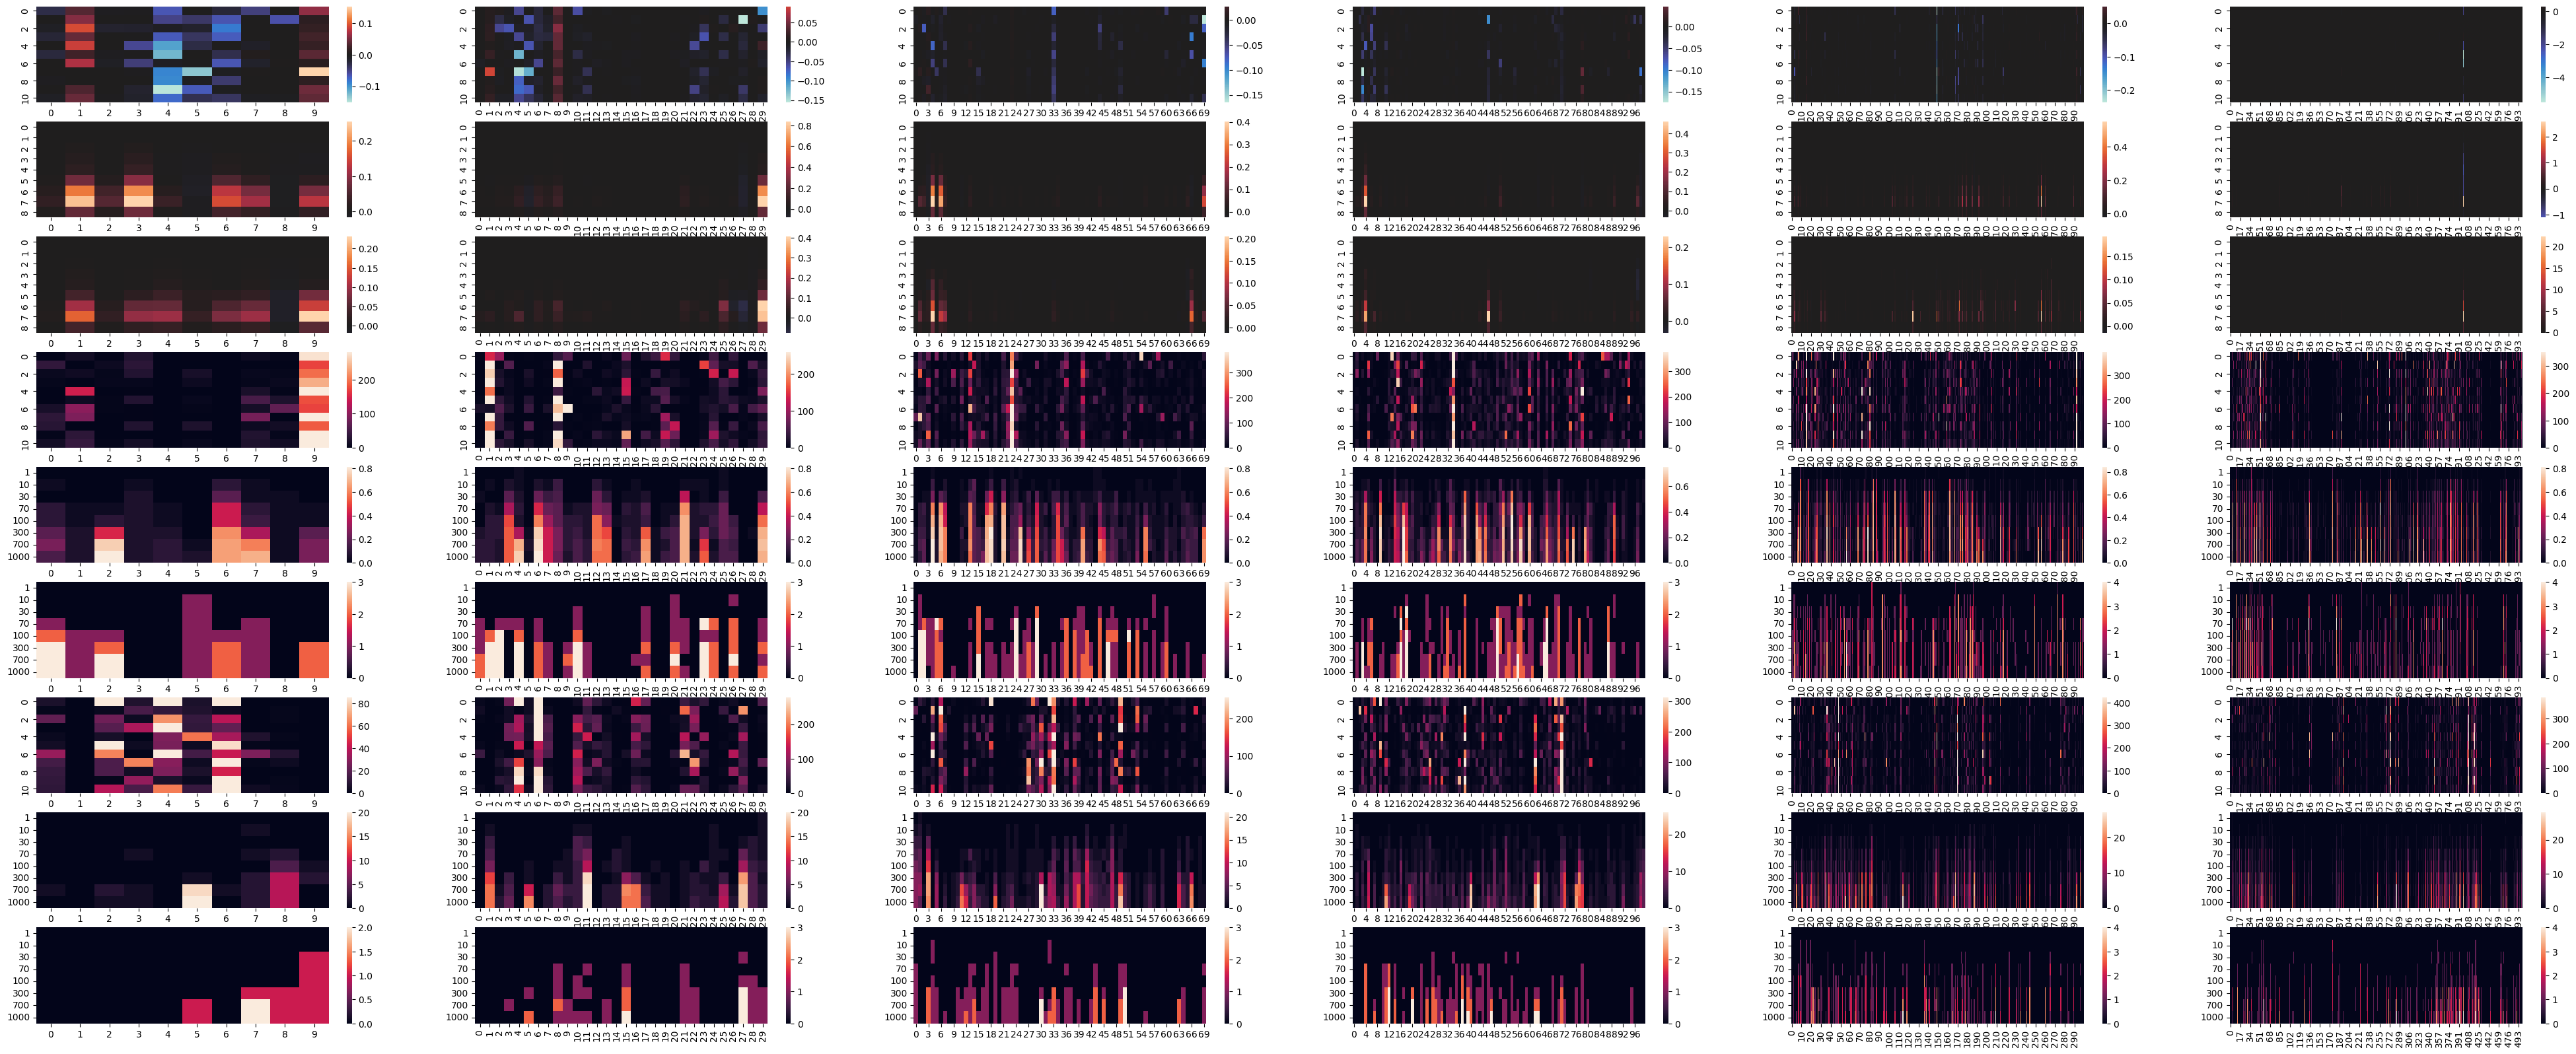

In [11]:
exp_id = 1
studied_bias = 4
concept_range = range(0,6)
concept_amounts = [10, 30, 70, 100, 300, 500, 700]
fig, axes = plt.subplots(9, len(concept_range), figsize=(50,20))
for index, concept_id in enumerate(concept_range):
    amount_of_concept = concept_amounts[concept_id]
    with open(f"models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
        bias_res = pkl.load(f)
    with open(f"models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
        concept_res = pkl.load(f)
    table = []
    for i in range(10):
        table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
    table.append(sum(table)/len(table))

    table1 = []
    for i in range(10):
        table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
    table1.append(sum(table1)/len(table1))

    table2 = []
    for i in range(10):
        table2.append(((bias_res[studied_bias][i][1] == 0) & (bias_res[studied_bias][i][0] > 0)).sum(axis=0))
    table2.append(sum(table2)/len(table2))

    neg_added = []
    neg_removed = []
    pos_added = []
    pos_removed = []
    raw_n_diff = []
    raw_p_diff = []
    for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
        table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
        neg_added.append(table_[0]/table_[2])
        neg_removed.append(table_[1])
        pos_added.append(table_[3])
        pos_removed.append(table_[4])
        raw_n_diff.append(table_[6])
        raw_p_diff.append(table_[7])
    raw_n_diff.append(sum(raw_n_diff)/len(raw_n_diff))
    raw_p_diff.append(sum(raw_p_diff)/len(raw_p_diff))

    sb.heatmap(table, center=0, annot=False, ax=axes[0][index])
    sb.heatmap(raw_n_diff, center=0, ax=axes[1][index])
    sb.heatmap(raw_p_diff, center=0, ax=axes[2][index])
    sb.heatmap(table1, vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[3][index])
    sb.heatmap(table2, vmin=0, vmax=table2[-1].max(), annot=False, ax=axes[6][index])
    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(neg_added, vmin=0, vmax=neg_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[4][index])

    # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
    sb.heatmap(neg_removed, vmin=0, vmax=neg_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[7][index])
    sb.heatmap(pos_added, vmin=0, vmax=pos_added[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[5][index])
    sb.heatmap(pos_removed, vmin=0, vmax=pos_removed[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[8][index])

    v_bias_identified = np.array(neg_added)
    v_bias_real = table1[-1]
    res = np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
    print(f"For {amount_of_concept} concept, the vector similarity is : {res}")

In [80]:
def normalize(a):
    b = (a - a.min())/(a.max() - a.min())
    return b/b.sum()

normalize(np.array(truc)) @ normalize(table1[-1]).T

array([6.19386430e-06, 5.43403792e-05, 1.21191960e-04, 2.01876017e-04,
       2.37653963e-04, 2.93349480e-04, 2.93510001e-04, 2.85641925e-04])

/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator NMF from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[Text(0.5, 23.52222222222222, 'Number of backpropagation step'),
 Text(50.722222222222214, 0.5, 'Number of concept'),
 Text(0.5, 1.0, 'Similarity between real and identified bias encoding')]

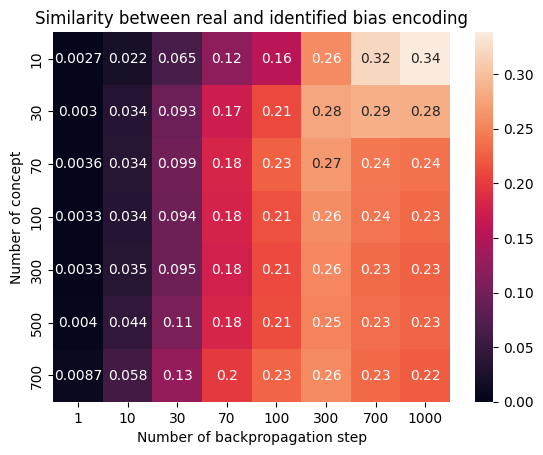

In [99]:
exp_range = range(5,10)
concept_range = range(0,7)
steps_amounts = [1, 10, 30, 70, 100, 300, 700, 1000]
concept_amounts = [10, 30, 70, 100, 300, 500, 700]

result = np.array([[0. for j in steps_amounts] for i in concept_range])
for exp_id in exp_range:
    temp_res = np.array([[0. for j in steps_amounts] for i in concept_range])
    for studied_bias in range(10):
        # fig, axes = plt.subplots(3, len(concept_range), figsize=(20,5))
        for index, concept_id in enumerate(concept_range):
            amount_of_concept = concept_amounts[concept_id]
            with open(f"models/{exp_name}/bias_{exp_id}_{concept_id}.pkl", "rb") as f:
                bias_res = pkl.load(f)
            with open(f"models/{exp_name}/concepts_{exp_id}_{concept_id}.pkl", "rb") as f:
                concept_res = pkl.load(f)
            table = []
            for i in range(10):
                table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
            table.append(sum(table)/len(table))
            # sb.heatmap(table[-1:], center=0, annot=False, ax=axes[0][index])

            table1 = []
            for i in range(10):
                table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
            table1.append(sum(table1)/len(table1))
            # sb.heatmap(table1[-1:], vmin=0, vmax=table1[-1].max(), annot=False, ax=axes[1][index])

            truc = []
            for step_amount in steps_amounts:
                table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
                truc.append(table_[0])
            v_bias_identified = np.array(truc)
            v_bias_real = table1[-1]
            temp_res[index] += np.dot(v_bias_identified, v_bias_real)/(np.linalg.norm(v_bias_identified)*np.linalg.norm(v_bias_real))
            # table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
            # sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000], ax=axes[2][index])
    result += (temp_res/10)
ax = sb.heatmap(result/len(exp_range), vmin=0, xticklabels=steps_amounts, yticklabels=concept_amounts, annot=True)
ax.set(xlabel="Number of backpropagation step", ylabel="Number of concept", title="Similarity between real and identified bias encoding")

In [111]:
from scipy.stats import kendalltau
a = np.array([3,2,1, 4, 9, 8, 6, 7, 5])
b = np.array([3,1,2,9, 8, 7, 5, 6, 4])
kendalltau(a, b)

SignificanceResult(statistic=np.float64(0.6666666666666666), pvalue=np.float64(0.012665343915343916))

In [112]:
kendalltau(np.argsort(a), np.argsort(b))

SignificanceResult(statistic=np.float64(0.5555555555555556), pvalue=np.float64(0.04461529982363316))

In [103]:
v_bias_identified[0].shape

(700,)

[Text(0.5, 23.52222222222222, 'Number of backpropagation step'),
 Text(50.722222222222214, 0.5, 'Number of concept'),
 Text(0.5, 1.0, 'Similarity between real and identified bias encoding')]

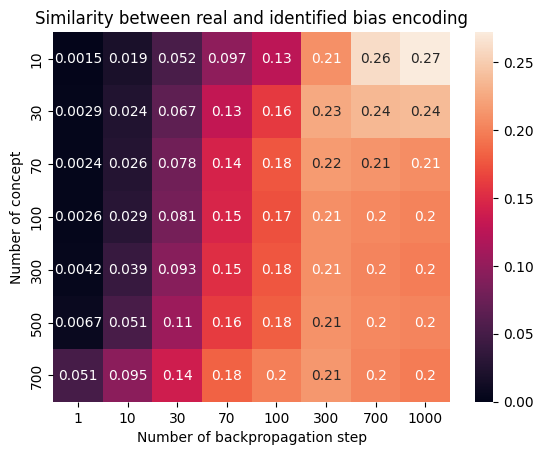

In [98]:
ax = sb.heatmap(result/len(exp_range), vmin=0, xticklabels=steps_amounts, yticklabels=concept_amounts, annot=True)
ax.set(xlabel="Number of backpropagation step", ylabel="Number of concept", title="Similarity between real and identified bias encoding")

<Axes: >

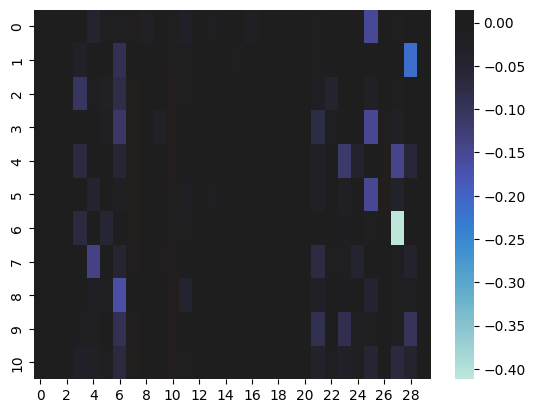

In [40]:
with open(f"models/{exp_name}/bias_{exp_id}_{1}.pkl", "rb") as f:
    bias_res = pkl.load(f)

table = []
for i in range(10):
    table.append((bias_res[studied_bias][i][1] - bias_res[studied_bias][i][0]).mean(axis=0))
table.append(sum(table)/len(table))
sb.heatmap(table, center=0, annot=False)

<Axes: >

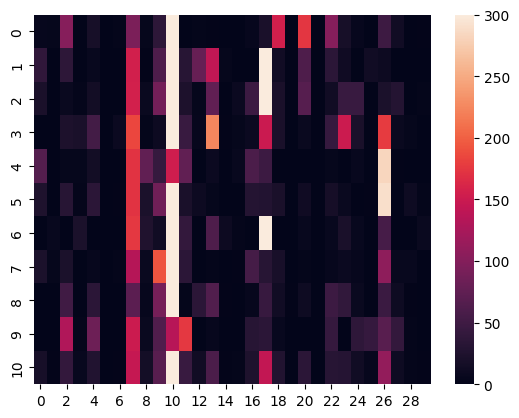

In [41]:
table1 = []
for i in range(10):
    table1.append(((bias_res[studied_bias][i][1] > 0) & (bias_res[studied_bias][i][0] == 0)).sum(axis=0))
table1.append(sum(table1)/len(table1))
sb.heatmap(table1, vmin=0, vmax=300, annot=False)   

<Axes: >

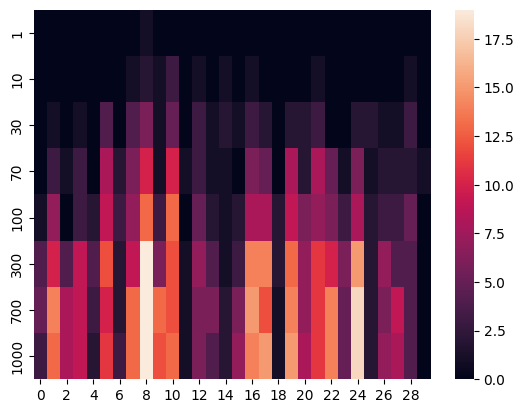

In [43]:
truc = []
for step_amount in [1, 10, 30, 70, 100, 300, 700, 1000]:
    table_ = cu.analyze_results(concept_res["concept_results"][step_amount], studied_bias, amount_of_concept)
    truc.append(table_[0])
# table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap(truc, vmin=0, vmax=truc[-1].max(), annot=False, yticklabels=[1, 10, 30, 70, 100, 300, 700, 1000])

<Axes: >

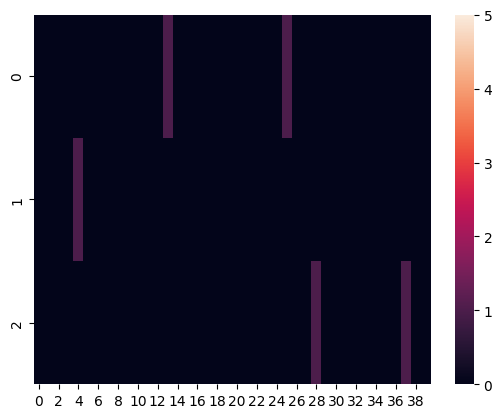

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

<Axes: >

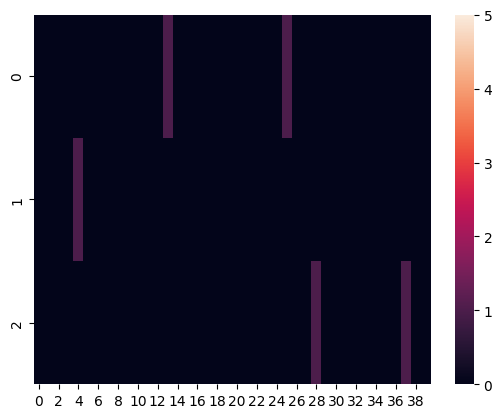

In [ ]:
table_ = cu.analyze_results(concept_res["concept_results"][10], studied_bias, 40)
table1 = [table_[0]/table_[2] - table_[1]/table_[2] - table_[3]/table_[4]]
sb.heatmap([table_[0], table_[1], table_[3]], vmin=0, vmax=5, annot=False)

In [30]:
table_

(array([0., 0., 2., 0., 2., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        1., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20., 20.,
        20.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.]),
 array([14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,
        14., 14., 14., 14., 14., 14., 14., 14., 14., 14., 14.,

In [17]:
data_path = os.getcwd() + "/data/MNIST"
device = "cuda"
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=res["batch_size"], data_label_correlation=res["test_correlation"], train=False)
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

assert(os.path.exists(f"models/{exp_name}/model_{exp_id}"))
model.load_state_dict(torch.load(f"models/{exp_name}/model_{exp_id}", weights_only=True))

base_acc = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 78.1%, Avg loss: 0.659705 



In [19]:
import seaborn as sb

<Axes: >

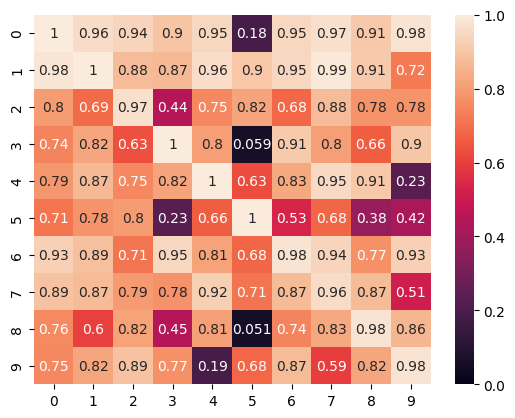

In [21]:
sb.heatmap(base_acc, vmin=0, vmax=1, annot=True)

<Axes: >

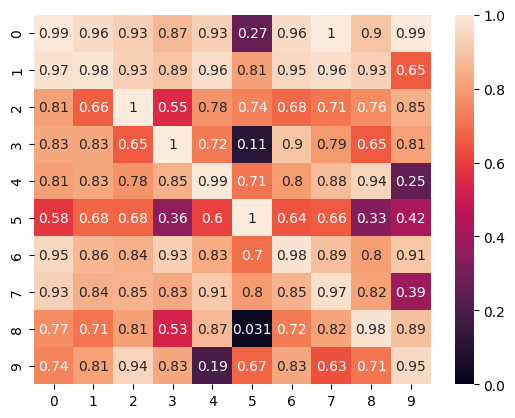

In [20]:
sb.heatmap(res["accuracy_matrix"], vmin=0, vmax=1, annot=True)